In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import csv
import cartopy.crs as ccrs
from shapely.geometry import Point
from shapely.geometry import LineString
import shapely.wkt
import movingpandas as mpd
from shapely.geometry import Point
from datetime import timedelta
import trackintel as ti
import glob

## General Functions

Save/Load Functions

In [10]:
def load_file(step = None,file_number = None, driver = "GPKG"):
    if step:
        folder = glob.glob(f"Data/{step}_*")[0]
        file_path = f"{folder}/{step}_{file_number}.{driver.lower()}"
        return gpd.read_file(file_path)
    else:
        print("Failed to save: No step provided.")

def save_file(step = None,file_number = None, variable_name = None, driver = "GPKG"):
    if step:
        folder = glob.glob(f"Data/{step}_*")[0]
        file_path = f"{folder}/{step}_{file_number}.{driver.lower()}"
        variable_name.to_file(file_path, driver=driver)
    else:
        print("Failed to save: No step provided.")


In [25]:
def reduction_stats(step, points = 0 , trajectory = 0):
    reduction_stats = pd.read_csv("Data/Reduction_Stats.csv")
    reduction_stats.drop(reduction_stats[reduction_stats['Step'] == step].index, inplace=True)
    reduction_stats = pd.concat([reduction_stats, pd.DataFrame({
        'Step': [step],
        'Points':[points],
        'Trajectory': [trajectory] 
    })], ignore_index=True)
    reduction_stats.to_csv("Data/Reduction_Stats.csv", index=False)

## 1 Splitting the tsv up so it can be handled by the limted memory

In [5]:
def split_tsv_file_by_id(input_file, id_column_name="Hashed Device ID", 
                         lines_per_file=10000, output_prefix='chunk_'):

    with open(input_file, 'r', newline='', encoding='utf-8') as infile:
        reader = csv.reader(infile, delimiter='\t')
        headers = next(reader)

        # Find the column index for the ID
        id_index = headers.index(id_column_name)

        file_count = 1
        current_file = None
        writer = None
        current_lines = 0
        current_id = None

        for row in reader:
            row_id = row[id_index]

            # If this is the first row OR the ID changes,
            # check if we need to start a new file
            if current_id is not None and row_id != current_id:
                if current_lines >= lines_per_file:
                    # Close previous file
                    current_file.close()
                    current_file = None
                    current_lines = 0

            # If no file open, start a new one
            if current_file is None:
                output_filename = f"{output_prefix}{file_count}.tsv"
                current_file = open(output_filename, 'w', newline='', encoding='utf-8')
                writer = csv.writer(current_file, delimiter='\t')
                writer.writerow(headers)
                file_count += 1

            # Write the row
            writer.writerow(row)
            current_lines += 1
            current_id = row_id

        if current_file:
            current_file.close()

In [8]:
split_tsv_file_by_id("Data/0_GPS/2022_GPS_Points_Copy.tsv", lines_per_file=1000000, output_prefix='Data/1_Split/1_')

## 2 Converting to gpkg and masking points outside the area of interest

In [ ]:
points_after = 0
mask = gpd.read_file("Data/Banks_Mask_Buffered.gpkg")
mask = mask.to_crs(epsg=2193)
for i in range(1, 35):
    gps_points_chunk_df = load_file(step=1, file_number=i, driver="TSV")

    # Create geometry column from lon/lat
    geometry = [Point(xy) for xy in zip(gps_points_chunk_df["Longitude of Visit"], gps_points_chunk_df["Latitude of Visit"])]

    # Build GeoDataFrame
    gps_points_chunk_gdf = gpd.GeoDataFrame(gps_points_chunk_df, geometry=geometry)

    gps_points_chunk_gdf.crs = "EPSG:4326"  # WGS84 Latitude/Longitude
    gps_points_chunk_gdf = gps_points_chunk_gdf.to_crs(epsg=2193)  # Convert to NZTM2000

    gps_points_chunk_masked_gdf = gpd.sjoin(gps_points_chunk_gdf, mask, how="inner", predicate='within')
    
    points_after += len(gps_points_chunk_masked_gdf)
    save_file(2, i, gps_points_chunk_masked_gdf)
    print(f"Processed chunk {i} of 34")
    

reduction_stats("Masked", points_after)

Processed chunk 1 of 34
Processed chunk 2 of 34
Processed chunk 3 of 34
Processed chunk 4 of 34
Processed chunk 5 of 34
Processed chunk 6 of 34
Processed chunk 7 of 34
Processed chunk 8 of 34
Processed chunk 9 of 34
Processed chunk 10 of 34
Processed chunk 11 of 34
Processed chunk 12 of 34
Processed chunk 13 of 34
Processed chunk 14 of 34
Processed chunk 15 of 34
Processed chunk 16 of 34
Processed chunk 17 of 34
Processed chunk 18 of 34
Processed chunk 19 of 34
Processed chunk 20 of 34
Processed chunk 21 of 34
Processed chunk 22 of 34
Processed chunk 23 of 34
Processed chunk 24 of 34
Processed chunk 25 of 34
Processed chunk 26 of 34
Processed chunk 27 of 34
Processed chunk 28 of 34
Processed chunk 29 of 34
Processed chunk 30 of 34
Processed chunk 31 of 34
Processed chunk 32 of 34
Processed chunk 33 of 34
Processed chunk 34 of 34


ValueError: All arrays must be of the same length

## 3 Removing Duplicate or Nan Data

In [ ]:
points_after = 0
for i in range(1, 35):

    gps_points_chunk = load_file(step=2, file_number=i, driver="GPKG")

    #### Remove Duplicates ####
    # Boolean mask: rows that are duplicates
    mask_duplicates = ~gps_points_chunk.duplicated(subset=['Hashed Device ID','Unix Timestamp of Visit'])
    removed_duplicates = gps_points_chunk[~mask_duplicates]

    # Apply the filter
    gps_points_no_duplicates = gps_points_chunk[mask_duplicates]

    print(f'Dropped Duplicates; ({len(removed_duplicates)} rows dropped)')

    #### Remove NaNs ####
    mask_nans = gps_points_no_duplicates[['Hashed Device ID','Latitude of Visit','Longitude of Visit','Date','Time of Day']].isna().any(axis=1)
    removed_nans = gps_points_no_duplicates[mask_nans]

    # Apply the filter
    gps_points_no_nans = gps_points_no_duplicates[~mask_nans]

    print(f'Dropped NaN ({len(removed_nans)} rows dropped)')
    points_after += len(gps_points_no_nans)
    
    save_file(3, i, gps_points_no_nans) 


reduction_stats("Cleaned", points_after)

Dropped Duplicates; (1984 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1983 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (2207 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (2157 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1399 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (995 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1516 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1412 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1046 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1066 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1135 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1339 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (812 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1189 rows dropped)
Dropped NaN (0 rows dropped)
Dropped Duplicates; (1274 rows dropp

## 4 Generate and remove home location Points

### Generating Home Locations

In [ ]:
for i in range(1, 35):
    # Load GPS samples from previous processing step
    gps_samples_gdf = load_file(step=3, file_number=i, driver="GPKG")
    
    # ---- Data Preparation ----
    gps_samples_gdf.to_crs(epsg=2193, inplace=True)
    gps_samples_gdf["Unix Timestamp of Visit"] = gps_samples_gdf["Unix Timestamp of Visit"].astype(int)
    gps_samples_gdf["timestamp"] = pd.to_datetime(gps_samples_gdf["Unix Timestamp of Visit"], unit="s")
    
    # Select only required columns
    gps_samples_gdf = gps_samples_gdf[["Hashed Device ID", "timestamp", "geometry", "Time Zone"]]
    
    # ---- Timezone Handling ----
    # Localize to UTC, then convert to Pacific/Auckland timezone
    gps_samples_gdf["timestamp"] = (
        pd.to_datetime(gps_samples_gdf["timestamp"])
        .dt.tz_localize("UTC")
        .dt.tz_convert("Pacific/Auckland")
    )
    
    # ---- Initialize trackintel PositionFixes ----
    gps_sample_ti = ti.io.read_positionfixes_gpd(
        gdf=gps_samples_gdf,
        tracked_at="timestamp", 
        user_id="Hashed Device ID", 
        geom_col="geometry",
        crs=2193
    )
    
    # ---- Filter for Late-Night Hours (20:00 - 06:00) ----
    # Extract hour and select records between 8pm and 6am
    gps_sample_ti['hour'] = gps_sample_ti['tracked_at'].dt.hour
    gps_sample_ti_late = gps_sample_ti[(gps_sample_ti['hour'] >= 20) | (gps_sample_ti['hour'] < 6)]
    gps_sample_ti = gps_sample_ti.drop('hour', axis=1)
    gps_sample_ti_late = gps_sample_ti_late.drop('hour', axis=1)
    
    # ---- Generate Staypoints ----
    # Identify stationary locations (home locations based on late-night clustering)
    gps_sample_ti_late, gps_home_staypoints = gps_sample_ti_late.generate_staypoints(
        method='sliding',
        distance_metric='haversine',
        dist_threshold=200,           # 200m radius
        time_threshold=5,              # minimum 5 minutes
        gap_threshold=1000.0,
        include_last=False,
        print_progress=False,
        exclude_duplicate_pfs=True,
        n_jobs=1
    )
    
    # ---- Generate Locations from Staypoints ----
    gps_home_staypoints, gps_home_locations = gps_home_staypoints.generate_locations(
        agg_level='user',
        num_samples=5,
        epsilon=200
    )
    gps_home_locations.drop('extent', axis=1, inplace=True)
    gps_home_locations.to_file("Data/GPS_Sample_Locations.gpkg", driver="GPKG")
    
    # ---- Buffer and Save Home Locations ----
    # Create 200m buffer around home location centers
    gps_home_locations_buffered = gps_home_locations.copy()
    gps_home_locations_buffered["geometry"] = gps_home_locations_buffered.center.buffer(200)
    gps_home_locations_buffered.drop('center', axis=1, inplace=True)
    
    save_file(4, i, gps_home_locations_buffered)

Data\3_Cleaned/3_1.gpkg
Data\3_Cleaned/3_2.gpkg
Data\3_Cleaned/3_3.gpkg
Data\3_Cleaned/3_4.gpkg
Data\3_Cleaned/3_5.gpkg
Data\3_Cleaned/3_6.gpkg
Data\3_Cleaned/3_7.gpkg
Data\3_Cleaned/3_8.gpkg
Data\3_Cleaned/3_9.gpkg
Data\3_Cleaned/3_10.gpkg
Data\3_Cleaned/3_11.gpkg
Data\3_Cleaned/3_12.gpkg
Data\3_Cleaned/3_13.gpkg
Data\3_Cleaned/3_14.gpkg
Data\3_Cleaned/3_15.gpkg
Data\3_Cleaned/3_16.gpkg
Data\3_Cleaned/3_17.gpkg
Data\3_Cleaned/3_18.gpkg
Data\3_Cleaned/3_19.gpkg
Data\3_Cleaned/3_20.gpkg
Data\3_Cleaned/3_21.gpkg
Data\3_Cleaned/3_22.gpkg
Data\3_Cleaned/3_23.gpkg
Data\3_Cleaned/3_24.gpkg
Data\3_Cleaned/3_25.gpkg
Data\3_Cleaned/3_26.gpkg
Data\3_Cleaned/3_27.gpkg
Data\3_Cleaned/3_28.gpkg
Data\3_Cleaned/3_29.gpkg
Data\3_Cleaned/3_30.gpkg
Data\3_Cleaned/3_31.gpkg
Data\3_Cleaned/3_32.gpkg
Data\3_Cleaned/3_33.gpkg
Data\3_Cleaned/3_34.gpkg


### Removing Home Location Datapoints

In [ ]:
points_after = 0
for i in range(1, 35):
    gps_home_locations_buffered = load_file(step=4,file_number=i, driver="GPKG")
    gps_samples_gdf = load_file(step=3, file_number=i, driver="GPKG")

    gps_home_locations_buffered.to_crs(epsg=2193, inplace=True)
    gps_home_locations_buffered =gps_home_locations_buffered.dissolve(by='user_id')
    gps_home_locations_buffered["user_id"] = gps_home_locations_buffered.index
    gps_home_locations_buffered.index = gps_home_locations_buffered["id"]
    
    gps_samples_gdf.to_crs(epsg=2193, inplace=True)
    gps_samples_gdf.rename(columns={"Hashed Device ID": "user_id"}, inplace=True)
    # Spatial join: points within polygons
    within_locations = gpd.sjoin(
        gps_samples_gdf,
        gps_home_locations_buffered[["user_id", "geometry"]],
        how="inner",
        predicate="within"
    )

    # Keep only rows where user IDs match
    matched = within_locations[within_locations["user_id_left"] == within_locations["user_id_right"]]

    # Remove matched points from the original points GeoDataFrame
    gps_sample_home_filtered = gps_samples_gdf.loc[
        ~gps_samples_gdf.index.isin(matched.index)
    ].copy()
    save_file(5,i,gps_sample_home_filtered)
    points_after += len(gps_sample_home_filtered)

reduction_stats("Home Location Filtered", points_after)

## 5 Generating Triplegs

In [28]:
points_after = 0
trajectories_after = 0
for i in range(1, 35):
    gps_sample_filtered = load_file(step=5, file_number=i, driver="GPKG")
    
    # ---- Data Preparation ----
    gps_sample_filtered["Unix Timestamp of Visit"] = gps_sample_filtered["Unix Timestamp of Visit"].astype(int)
    gps_sample_filtered["timestamp"] = pd.to_datetime(gps_sample_filtered["Unix Timestamp of Visit"], unit="s")
    gps_sample_filtered["timestamp"] = (
        pd.to_datetime(gps_sample_filtered["timestamp"])
        .dt.tz_localize("UTC")
        .dt.tz_convert("Pacific/Auckland")
    )
    gps_sample_filtered = gps_sample_filtered[["field_1","user_id","Unix Timestamp of Visit", "timestamp", "geometry"]]
    # Sort by user and timestamp
    gps_sample_filtered = gps_sample_filtered.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
    
    # ---- Generate Triplegs ----
    # Build trajectories by grouping consecutive points, splitting on time gaps and stops
    triplegs_list = []
    
    for user_id, user_group in gps_sample_filtered.groupby("user_id"):
        user_group = user_group.sort_values("timestamp").reset_index(drop=True)
        
        # Initialize first trajectory segment
        current_points = [user_group.geometry.iloc[0]]
        current_timestamps = [user_group["timestamp"].iloc[0]]
        
        for idx in range(1, len(user_group)):
            time_gap = (user_group["timestamp"].iloc[idx] - current_timestamps[-1]).total_seconds()
            
            # Check if time gap exceeds threshold (300 seconds = 5 minutes)
            if time_gap > 300.0:
                # Save the completed trajectory if it has enough points
                if len(current_points) >= 3:
                    line_geom = LineString(current_points)
                    triplegs_list.append({
                        "user_id": user_id,
                        "started_at": current_timestamps[0],
                        "finished_at": current_timestamps[-1],
                        "geometry": line_geom
                    })
                
                # Start new trajectory segment
                current_points = [user_group.geometry.iloc[idx]]
                current_timestamps = [user_group["timestamp"].iloc[idx]]
            else:
                # Add point to current trajectory
                current_points.append(user_group.geometry.iloc[idx])
                current_timestamps.append(user_group["timestamp"].iloc[idx])
                
                # ---- Detect Stop (Staypoint) ----
                # Trigger stop when the last 2 points are within 30m and span >15 minutes
                if len(current_points) >= 2:
                    recent_points = current_points[-2:]
                    recent_timestamps = current_timestamps[-2:]
                    
                    # Distance between the two recent points
                    dist_recent = recent_points[0].distance(recent_points[1])
                    
                    # Timespan in seconds
                    timespan = (recent_timestamps[-1] - recent_timestamps[0]).total_seconds()
                    
                    if dist_recent <= 100 and timespan > 600:
                        # Stop detected - save trajectory before the stop
                        # Exclude the last 2 points (the stop evidence)
                        if len(current_points) > 2:
                            line_geom = LineString(current_points[:-2])
                            # finished_at is the third-last timestamp
                            triplegs_list.append({
                                "user_id": user_id,
                                "started_at": current_timestamps[0],
                                "finished_at": current_timestamps[-3],
                                "geometry": line_geom
                            })
                        
                        # Start new trajectory after the stop, beginning with the current point
                        current_points = [user_group.geometry.iloc[idx]]
                        current_timestamps = [user_group["timestamp"].iloc[idx]]
        
        # Save the last trajectory segment if it has enough points
        if len(current_points) >= 3:
            line_geom = LineString(current_points)
            triplegs_list.append({
                "user_id": user_id,
                "started_at": current_timestamps[0],
                "finished_at": current_timestamps[-1],
                "geometry": line_geom
            })
    
    # Convert to GeoDataFrame
    gps_sample_triplegs = gpd.GeoDataFrame(triplegs_list, crs=2193)
    
    points_after += gps_sample_triplegs.count_coordinates().sum()
    trajectories_after += len(gps_sample_triplegs)
    print(f"Chunk {i}: Generated {len(gps_sample_triplegs)} triplegs")
    save_file(6, i, gps_sample_triplegs)

reduction_stats("Triplegs Generated", points_after, trajectories_after)

Chunk 1: Generated 5752 triplegs
Chunk 2: Generated 5908 triplegs
Chunk 3: Generated 6197 triplegs
Chunk 4: Generated 6246 triplegs
Chunk 5: Generated 4178 triplegs
Chunk 6: Generated 3840 triplegs
Chunk 7: Generated 4188 triplegs
Chunk 8: Generated 4746 triplegs
Chunk 9: Generated 3691 triplegs
Chunk 10: Generated 3914 triplegs
Chunk 11: Generated 4177 triplegs
Chunk 12: Generated 5126 triplegs
Chunk 13: Generated 3934 triplegs
Chunk 14: Generated 4883 triplegs
Chunk 15: Generated 5418 triplegs
Chunk 16: Generated 5227 triplegs
Chunk 17: Generated 4388 triplegs
Chunk 18: Generated 4445 triplegs
Chunk 19: Generated 5286 triplegs
Chunk 20: Generated 5620 triplegs
Chunk 21: Generated 5681 triplegs
Chunk 22: Generated 6281 triplegs
Chunk 23: Generated 6207 triplegs
Chunk 24: Generated 6942 triplegs
Chunk 25: Generated 6567 triplegs
Chunk 26: Generated 6402 triplegs
Chunk 27: Generated 7101 triplegs
Chunk 28: Generated 6713 triplegs
Chunk 29: Generated 6620 triplegs
Chunk 30: Generated 585

## 6 Classifying Transport Mode

In [52]:
points_before = 0
points_after = 0
trips_before = 0
trips_after = 0
def classify_by_speed_kmh(speed_kmh):
    if pd.isna(speed_kmh):
        return "unknown"
    # Threshold: <=15 km/h treated as walking/cycling, otherwise motorized
    return "walk_cycle" if speed_kmh <= 15 else "motorized"

for i in range(1, 35):
    triplegs = load_file(step=6, file_number=i, driver="GPKG")

    # Ensure time columns are datetime with timezone awareness
    triplegs["started_at"] = pd.to_datetime(triplegs["started_at"])
    triplegs["finished_at"] = pd.to_datetime(triplegs["finished_at"])

    # Duration (seconds) and length (meters); guard against zero/negative durations
    triplegs["duration_s"] = (triplegs["finished_at"] - triplegs["started_at"]).dt.total_seconds()
    triplegs["duration_s"] = triplegs["duration_s"].where(triplegs["duration_s"] > 0, np.nan)

    # Speed km/h: length (m) / time (s) * 3.6
    triplegs["speed_kmh"] = (triplegs.geometry.length / triplegs["duration_s"]) * 3.6

    # Classify by speed
    triplegs["mode"] = triplegs["speed_kmh"].apply(classify_by_speed_kmh)

    print(f"Chunk {i}: {triplegs['mode'].value_counts(dropna=False).to_dict()}")
    points_before += triplegs.count_coordinates().sum()
    trips_before += len(triplegs)
    points_after += triplegs[triplegs["mode"]=="walk_cycle"].count_coordinates().sum()
    trips_after += len(triplegs[triplegs["mode"]=="walk_cycle"])

    save_file(7, i, triplegs)

size_df = pd.read_csv("Data/Point_Stats.csv")
size_df = pd.concat([size_df, pd.DataFrame({
    'Step': ['Classiffication'],
    'Points Before': [points_before],
    'Points After': [points_after]
})], ignore_index=True)
size_df.to_csv("Data/Point_Stats.csv", index=False)

tripleg_size_stats = pd.DataFrame({
    'Step': ['Classiffication'],
    'Triplegs Before': [trips_before],
    'Triplegs After': [trips_after]
})
tripleg_size_stats.to_csv("Data/Tripleg_Stats.csv", index=False)

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-01-11T14:21:40.000+13:00, successfully parsed
  return ogr_read(


Chunk 1: {'walk_cycle': 2923, 'motorized': 2829}


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-01-11T12:04:18.000+13:00, successfully parsed
  return ogr_read(


Chunk 2: {'walk_cycle': 3021, 'motorized': 2887}


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-01-25T18:49:32.000+13:00, successfully parsed
  return ogr_read(


...

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-12-02T13:22:37.000+13:00, successfully parsed
  return ogr_read(


Chunk 32: {'walk_cycle': 4618, 'motorized': 2378}


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-12-17T14:04:06.000+13:00, successfully parsed
  return ogr_read(


Chunk 33: {'walk_cycle': 4268, 'motorized': 2571}
Chunk 34: {'walk_cycle': 959, 'motorized': 415}


c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-12-04T07:33:30.000+13:00, successfully parsed
  return ogr_read(


## 7 Formating Trips for FMM

In [57]:
for i in range(1, 35):
    gps_transport_mode = load_file(step=7, file_number=i, driver="GPKG")
    trips_for_matching = gps_transport_mode[gps_transport_mode["mode"]=="walk_cycle"].to_crs(epsg=2193)
    
    trips_for_matching["middle_time"] = trips_for_matching["started_at"]
    trips_for_matching.drop(columns=["mode","started_at","finished_at","speed_kmh","duration_s"], inplace=True)
    trips_for_matching['id']= trips_for_matching.index.astype(str)
    save_file(8,i,trips_for_matching)

    trips_for_matching.drop(columns=["user_id"], inplace=True)
    trips_for_matching["geometry"] = trips_for_matching.geometry.to_wkt()
    trips_for_matching.to_csv(
        f"Data/8_Fmm_Formated/8_{i}.csv",
        sep=";",
        index=False,
        quoting=csv.QUOTE_NONE,
        escapechar="\\",
        lineterminator="\n"
    )

c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-01-11T14:21:40.000+13:00, successfully parsed
  return ogr_read(
C:\Users\maxwe\AppData\Local\Temp\ipykernel_304\2745225069.py:11: UserWarning: Geometry column does not contain geometry.
  trips_for_matching["geometry"] = trips_for_matching.geometry.to_wkt()
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started_at, 2022-01-11T12:04:18.000+13:00, successfully parsed
  return ogr_read(
C:\Users\maxwe\AppData\Local\Temp\ipykernel_304\2745225069.py:11: UserWarning: Geometry column does not contain geometry.
  trips_for_matching["geometry"] = trips_for_matching.geometry.to_wkt()
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column started

## 9 Managing FMM Results

### Matching Trips to Matched Trips

In [1]:
points_before = 0
points_after = 0
trips_before = 0
trips_after = 0
for i in range(1, 2):
    fmm_results = pd.read_csv(f"Data/9_Matched_Results/9_{i}.csv")
    fmm_results.sort_values(by=["id"], inplace=True)
    fmm_results.drop(columns=["Unnamed: 0","mgeom","opath"], inplace=True)
    fmm_results.dropna(inplace=True)
    fmm_results["id"]   = fmm_results["id"].astype(str)
    trips_for_matching = load_file(step=8, file_number=i)
    trips_for_matching.sort_values(by=["id"], inplace=True)

    joined = trips_for_matching.merge(fmm_results, on="id", how="left")

    points_before += trips_for_matching.count_coordinates().sum()
    trips_before += len(trips_for_matching)

    points_after += joined.dropna(subset=["cpath"]).count_coordinates().sum()
    trips_after += len(joined.dropna(subset=["cpath"]))
    save_file(10,i,joined)

size_df = pd.read_csv("Data/Point_Stats.csv")
size_df = pd.concat([size_df, pd.DataFrame({
    'Step': ['Map_Matching'],
    'Points Before': [points_before],
    'Points After': [points_after]
})], ignore_index=True)
size_df.to_csv("Data/Point_Stats.csv", index=False)

tripleg_size_stats = pd.read_csv("Data/Tripleg_Stats.csv")
tripleg_size_stats = pd.concat([tripleg_size_stats, pd.DataFrame({
    'Step': ['Map_Matching'],
    'Triplegs Before': [trips_before],
    'Triplegs After': [trips_after]
})], ignore_index=True)
tripleg_size_stats.to_csv("Data/Tripleg_Stats.csv", index=False)

NameError: name 'pd' is not defined

___

### Matching Trips to Each OSM Route ID

In [ ]:

full_gdf = gpd.GeoDataFrame()
for i in range(1, 35):
    fmm_matched = load_file(step=10, file_number=i)
    fmm_matched.to_crs(epsg=2193, inplace=True)
    fmm_matched.rename(columns={"geometry":"trip_geometry","id":"track_id"}, inplace=True)
    fmm_matched["track_id"]= fmm_matched["track_id"]+f"_{i}"
    exploded_osm = (
        fmm_matched["cpath"]
        .dropna()
        .str.split(",")
        .explode()
        .str.strip()
        .to_frame(name="id")
    )
    exploded_osm = exploded_osm.merge(fmm_matched, left_index=True, right_index=True)
    full_gdf = pd.concat([full_gdf, exploded_osm], ignore_index=True)

trips_before = len(full_gdf["track_id"].unique())

full_gdf = full_gdf[full_gdf["id"]!="0"]
full_gdf["id"] = full_gdf["id"].astype(int)
full_gdf.sort_values(by ="id", inplace=True)

osm_routes = gpd.read_file("Data/OSM_Edges.gpkg")
osm_routes.to_crs(epsg=2193, inplace=True)
osm_routes["id"] = osm_routes.index.astype(int)
osm_routes.sort_values(by ="id", inplace=True)

merged = full_gdf.merge(osm_routes[["id","highway","geometry"]], on="id", how="left", suffixes=('', '_osm'))

merged_gdf = gpd.GeoDataFrame(merged, geometry="geometry", crs=2193)



merged_gdf["trip_geometry"] = merged_gdf["trip_geometry"].to_wkt()

merged_gdf.to_file("Data/Final_Matched.gpkg", driver="GPKG")




c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column middle_time, 2022-01-11T14:21:40.000+13:00, successfully parsed
  return ogr_read(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column middle_time, 2022-01-11T12:04:18.000+13:00, successfully parsed
  return ogr_read(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column middle_time, 2022-01-25T19:25:59.000+13:00, successfully parsed
  return ogr_read(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column middle_time, 2022-02-12T08:13:30.000+13:00, successfully parsed
  return ogr_read(
c:\Users\maxwe\anaconda3\envs\geospatial_study\Lib\site-packages\pyogrio\raw.py:

## 10 Highway Filtering

In [3]:
match_results = gpd.read_file("Data/Final_Matched.gpkg")
match_results_subset = match_results.copy()

FOOT_CYCLE_ONLY = {
    "track",
    "path",
    "cycleway",
    "footway"
}

def check_highway_match(highway_value):
    if isinstance(highway_value, str):
        # Try to parse string representation of list
        if highway_value.startswith('['):
            import ast
            try:
                highway_list = ast.literal_eval(highway_value)
            except:
                highway_list = [highway_value]
        else:
            highway_list = [highway_value]
    elif isinstance(highway_value, list):
        highway_list = highway_value
    else:
        highway_list = [highway_value]
    
    return bool(set(highway_list) & FOOT_CYCLE_ONLY)

match_results_subset = match_results_subset[
    match_results_subset["highway"].apply(check_highway_match)
]

match_results_subset.to_file("Data/Final_Matched_Filtered.gpkg", driver="GPKG")

In [5]:
len(match_results)
len(match_results_subset)

141637

<Axes: >

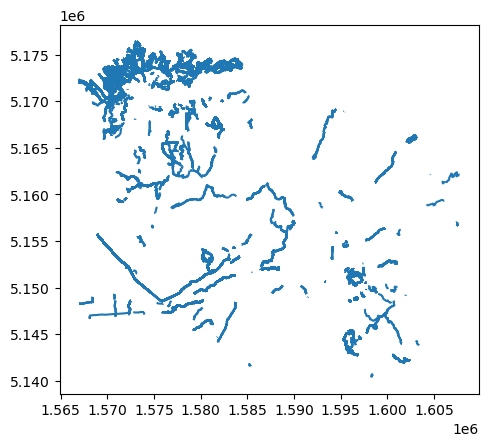

In [14]:
match_results_subset.plot()

In [16]:
len(match_results)

319553

In [ ]:
reduction_stats = pd.read_csv("Data/Final_Matched_Filtered.csv")

In [27]:
reduction_stats.loc[reduction_stats['Step']=="Highway_Filtered", "Trajectories"]=len(match_results_subset["track_id"].unique())

In [29]:
reduction_stats.to_csv("Data/Reduction_Stats.csv", index=False)

## 11 Finding track sections associated with DOC Counters

In [30]:
gps_data = gpd.read_file("Data/Final_Matched_Filtered.gpkg")

In [31]:
osm_routes = gpd.read_file("Data/OSM_Edges.gpkg")
osm_routes.to_crs(epsg=2193, inplace=True)

In [32]:
#Finding DOC Counter Locations
data = {'Techid': [394796, 28638, 305961, 304795, 88470, 46404, 34475, 34471, 34472, 'C20TA21', 93952, 'C20NP22'],
       
        'Easting': [1574786, 1577440, 1582547, 1583439, 1574369, 1575319, 1572418, 1576855, 1589463, 1589617, 1601270, 1595722],
        'Northing': [5169516, 5172989, 5174032, 5173846, 5160900, 5158671, 5151904, 5149008, 5158407, 5156299, 5155693, 5143315]
        }

df = pd.DataFrame(data)

geometry = gpd.points_from_xy(df['Easting'], df['Northing'])

Counter_Locations = gpd.GeoDataFrame(df['Techid'], geometry=geometry, crs = "EPSG:2193")

In [33]:
# Fiinding nearest track section to each counter location keeping gemotry of counter location and track section
nearest_tracks = gpd.sjoin_nearest(Counter_Locations, gps_data, how="left", lsuffix="counter", rsuffix="track", max_distance=50)
# Keep both geometries
nearest_tracks['geometry_track'] = nearest_tracks['id'].map(osm_routes.geometry)
nearest_tracks = nearest_tracks.set_geometry('geometry_track')


In [34]:
# Add associated id values from nearest_tracks to Counter_Locations as plain strings
Counter_Locations['cpath'] = Counter_Locations['Techid'].map(
    nearest_tracks.groupby('Techid')['id'].apply(lambda x: list(pd.Series(x).dropna().astype(str).unique()))
)

In [37]:
name = pd.read_csv("Data/Counter_Names.csv")

In [38]:
Counter_Locations["Name"] = name

In [39]:
Counter_Locations

,Techid,geometry,cpath,Name
0,394796,POINT (1574786 5169516),"[2494, 2431]",Otamahua Quail Island Track Counter
1,28638,POINT (1577440 5172989),[3970],Major Hornbrook Track Counter
2,305961,POINT (1582547 5174032),[10336],Pilgrims Way Track Counter
3,304795,POINT (1583439 5173846),[10562],Godley Head Summit Track Counter
4,88470,POINT (1574369 5160900),"[7579, 7594]",Gebbies Pass Track Counter
5,46404,POINT (1575319 5158671),[3112],Kaituna Vally Track Counter
6,34475,POINT (1572418 5151904),"[2759, 1376]",Motukarara To Birdlings Track Counter GW
7,34471,POINT (1576855 5149008),[1371],Birdlings Little River Track Counter GW
8,34472,POINT (1589463 5158407),"[2855, 4370]",Port Levy To Hilltop Track Counter
9,C20TA21,POINT (1589617 5156299),"[2849, 6705]",Counter Montgomery Reserve


In [40]:
Counter_Locations.to_file("Data/DOC_Counter_Locations.gpkg", driver="GPKG")